In [1]:
# title import pkg
import warnings

warnings.filterwarnings("ignore")

import sys
import os


import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#plt.style.use("ggplot")
sns.set_theme(style="ticks")
sns.set_context("paper")
sns.color_palette("husl", 8)
#plt.style.use('grayscale')

import re
from tqdm import tqdm
from IPython.display import clear_output

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import (
    LogisticRegressionCV,
    LassoCV,
    Lasso,
    LogisticRegression,
)


sys.path.append(os.path.abspath("../"))
from dmldid.model_ro import DMLDiD_RO

from dmldid.simdata_genrater import generate_simdata_ro

In [2]:
def naive_did(
    df,
    y1_col,
    y0_col,
    d_col,
) -> np.float:
    _pivot = df.groupby(d_col)[[y0_col, y1_col]].mean()
    _pivot["diff"] = _pivot.diff(axis=1)[y1_col]
    
    return _pivot["diff"].diff().values[-1]

In [3]:
y1_col = "postY"
y0_col = "preY"
d_col = "D"
df_ro = generate_simdata_ro(
            _dim=100, _n=200, base_seed=1, xd_unobserved=True
        )

In [4]:
df_ro.sample(5)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x93,x94,x95,x96,x97,x98,x99,D,preY,postY
5,-1.498665,0.204274,-0.689183,-0.203303,-0.185406,0.189293,-0.563789,0.089686,-0.601157,0.556074,...,1.710662,0.034944,1.453918,0.661681,0.986352,-0.466155,1.384991,0,-8.589357,-18.141717
52,0.201330,-1.413250,-0.370350,0.653883,0.275142,-0.372381,-1.117046,-0.427815,0.939184,-0.920710,...,0.979415,-0.813916,-0.313444,-1.141681,-0.782453,-1.015003,1.071549,1,-4.628636,-4.986467
96,-1.253990,-0.095627,-0.111218,0.816923,-0.738393,-1.211719,-1.034604,0.349004,-0.463044,-0.590044,...,0.595744,0.125241,-0.391006,0.621248,1.398024,0.194250,0.253733,0,-8.942511,-13.707396
22,0.208633,0.250496,1.329672,-0.695822,-0.675123,-0.756837,0.195746,-0.158472,0.777209,-0.789141,...,-0.849519,1.152007,0.175928,0.638986,1.020153,1.792613,-0.639097,1,-4.222344,1.572577
123,-0.099831,-0.755909,-1.489489,-0.259492,-0.339665,-0.041302,0.086401,1.192356,0.212806,0.008346,...,0.469926,0.879317,0.117589,0.305505,0.032830,0.287710,0.916465,1,-8.300762,-18.164887


In [5]:
naive_did_result = []
dmldid_lasso_result = []
abadie_lasso_result = []
# dmldid_lgbm_result = []
# abadie_lgbm_result = []
sim_cnt = 1000
for i in range(sim_cnt):
    df = generate_simdata_ro(_dim=100, _n=500, base_seed=i, xd_unobserved=True)
    X_cols = [col for col in df.columns if "x" in col]

    naive_did_result.append(
        naive_did(
            df,
            y1_col=y1_col,
            y0_col=y0_col,
            d_col=d_col,
        )
    )
    linear_dmldid = DMLDiD_RO(
        d_model=LogisticRegressionCV(
            cv=5, random_state=123, penalty="l1", solver="saga"
        ),
        l1k_model=LassoCV(cv=5, random_state=123),
    )
    linear_dmldid.fit(
        df,
        y1_col=y1_col,
        y0_col=y0_col,
        d_col=d_col,
        X_cols=X_cols,
        dmldid=False,
        base_random_seed=1,
    )
    abadie_lasso_result.append(linear_dmldid.att())

    linear_dmldid = DMLDiD_RO(
        d_model=LogisticRegressionCV(
            cv=5, random_state=123, penalty="l1", solver="saga"
        ),
        l1k_model=LassoCV(cv=5, random_state=123),
    )
    linear_dmldid.fit(
        df,
        y1_col=y1_col,
        y0_col=y0_col,
        d_col=d_col,
        X_cols=X_cols,
        dmldid=True,
        base_random_seed=1,
    )
    dmldid_lasso_result.append(linear_dmldid.att())

#     _dmldid = DMLDiD_RO(
#         d_model=LGBMClassifier(random_state=123),
#         l1k_model=LGBMRegressor(random_state=123),
#     )
#     _dmldid.fit(
#         df,
#         y1_col=y1_col,
#         y0_col=y0_col,
#         d_col=d_col,
#         X_cols=X_cols,
#         dmldid=True,
#         base_random_seed=123,
#     )
#     dmldid_lgbm_result.append(_dmldid.att())

#     _dmldid = DMLDiD_RO(
#         d_model=LGBMClassifier(random_state=123),
#         l1k_model=LGBMRegressor(random_state=123),
#     )
#     _dmldid.fit(
#         df,
#         y1_col=y1_col,
#         y0_col=y0_col,
#         d_col=d_col,
#         X_cols=X_cols,
#         dmldid=False,
#         base_random_seed=123,
#     )
#     abadie_lgbm_result.append(_dmldid.att())

    clear_output(wait=True)
    print(f"{i} naive DiD: ", np.mean(naive_did_result))
    print(f"{i} Abadie SemiDiD(Lasso): ", np.mean(abadie_lasso_result))
    print(f"{i} DMLDiD(Lasso): ", np.mean(dmldid_lasso_result))
#     print(f"{i} Abadie SemiDiD(lgbm): ", np.mean(abadie_lgbm_result))
#     print(f"{i} DMLDiD(lgbm): ", np.mean(dmldid_lgbm_result))

999 naive DiD:  9.617752755671528
999 Abadie SemiDiD(Lasso):  6.515880786592344
999 DMLDiD(Lasso):  3.001849782012795


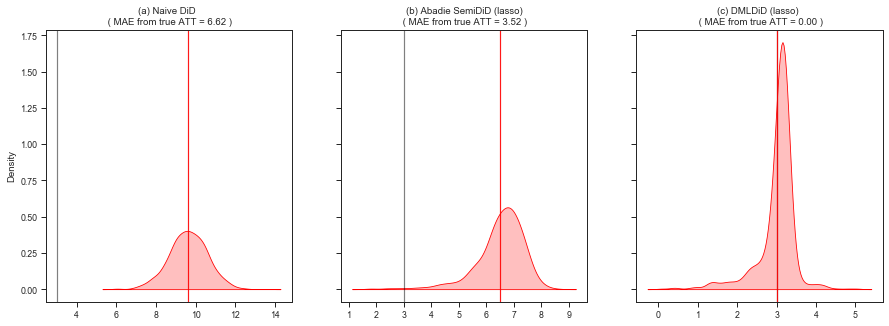

In [6]:
_label = [
    f"(a) Naive DiD \n ( MAE from true ATT = {np.abs(3-np.mean(naive_did_result)):.2f} )",
    f"(b) Abadie SemiDiD (lasso)\n ( MAE from true ATT = {np.abs(3-np.mean(abadie_lasso_result)):.2f} )",
    f"(c) DMLDiD (lasso) \n ( MAE from true ATT = {np.abs(3-np.mean( dmldid_lasso_result)):.2f} )",
]
result_df = pd.DataFrame(
    {
        "naive_did": naive_did_result,
        "abadie_lasso_result": abadie_lasso_result,
        "dmldid_lasso_result": dmldid_lasso_result
    }
)

fig, ax = plt.subplots(1, 3, sharex="col", sharey="row", figsize=(15, 5))
ax = ax.ravel()
for i, _col in enumerate(result_df.columns):
    sns.kdeplot(result_df[_col], shade=True, color="red", ax=ax[i])
    # ax[i].hist(result_df[_col], bins=50,color="red",alpha=0.5)
    #ax[i].set_xlim(-5,12.5)

    ax[i].set_title(_label[i])
    ax[i].axvline(x=3, alpha=0.5, color="black")
    ax[i].axvline(x=result_df[_col].mean(), color="red", alpha=0.9)
    ax[i].set_xlabel("")

fig.savefig("../fig/appendix_ro_lasso.png", dpi=300)
plt.show()

In [7]:
result_df.to_csv("../sim_results/ro_simdata_newdata_lasso.csv", index=False)

In [8]:
result_df.describe().T

,count,mean,std,min,25%,50%,75%,max
naive_did,1000.0,9.617753,0.967571,6.032014,8.993535,9.626350,10.274648,13.546060
abadie_lasso_result,1000.0,6.515881,0.871231,1.780098,6.167786,6.655510,7.086045,8.609241
dmldid_lasso_result,1000.0,3.001850,0.482629,0.089736,2.944592,3.109418,3.225774,5.038819


In [9]:
# _label = [
#     f"naive DiD \n ( MAE from true ATT = {np.abs(3-np.mean(naive_did_result)):.2f} )",
#     f"Abadie ASemiDiD (lgbm)\n ( MAE from true ATT = {np.abs(3-np.mean(abadie_lgbm_result)):.2f} )",
#     f"DMLDiD(lgbm) \n ( MAE from true ATT = {np.abs(3-np.mean( dmldid_lgbm_result)):.2f} )",
# ]
# result_df = pd.DataFrame(
#     {
#         "naive_did": naive_did_result,
#         "abadie_lgbm_result": abadie_lgbm_result,
#         "dmldid_lgbm_result": dmldid_lgbm_result
#     }
# )

# fig, ax = plt.subplots(1, 3, sharex="col", sharey="row", figsize=(10, 3))
# ax = ax.ravel()
# for i, _col in enumerate(result_df.columns):
#     sns.kdeplot(result_df[_col], shade=True, color="red", ax=ax[i])
#     # ax[i].hist(result_df[_col], bins=50,color="red",alpha=0.5)
#     #ax[i].set_xlim(-5,12.5)

#     ax[i].set_title(_label[i])
#     ax[i].axvline(x=3, alpha=0.5, color="black")
#     ax[i].axvline(x=result_df[_col].mean(), color="red", alpha=0.9)
#     ax[i].set_xlabel("")

# fig.savefig("../fig/appendix_ro_lgbm.png", dpi=300)
# plt.show()

In [10]:
# result_df.describe().T

In [11]:
# result_df.to_csv("../sim_results/ro_simdata_newdata_lgbm.csv", index=False)

In [12]:
print("Done")

Done
